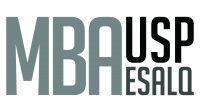

# Redes neurais com o Keras

O Keras é um pacote muito indicado para se iniciar a modelagem com redes neurais. É baseado em *Tensor Flow*, que é um dos melhores pacotes para se fazer RNA e *deep learning* ao lado do Pytorch. A filosofia do Keras é democratizar o uso do *deep learning*, então ele procura ter comandos muito mais práticos que o *Tensof Flow*. Agora, para quem quer se aprofundar no assunto, vale buscar conhecer o *Tensor Flow* ou o *Pytorch*.

Vale notar que é possível rodar o Keras no R, mas ele vai configurar uma interface com o Python, o que pode dar um certo trabalho.

## Instalando pacotes

Se você nunca mexeu com TensorFlow ou Keras, é provável que precise instalar alguns pacotes. Abaixo seguem os pacotes que eu instalei no meu computador para rodar os scripts abaixo.

Se você remover os comentários, vai ser necessário rodar estes comandos apenas uma vez.

In [ ]:
#!pip install tensorflow

In [ ]:
#!pip install keras

In [ ]:
#!pip install tensorflow_datasets

In [ ]:
#!pip install np_utils

In [ ]:
#!pip install keras

## Carregando os pacotes

Já carregar os pacotes é uma atividade que precisa ser feita a cada sessão aberta do Python.

Vamos utilizar basicamente alguns trexos do Keras, e o matplotlib para exibir as imagens.

In [27]:
import numpy as np
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Activation
# from keras.utils import np_utils
from tensorflow.keras.datasets import mnist
from matplotlib import pyplot as plt
from keras.utils import to_categorical

## Carregando os dados

Nesta primeira etapa, vamos carregar os dados do MNIST, um famoso conjunto de dados de dígitos numéricos, escritos à mão, cujo objetivo é se construir um algoritmo que, através dos dados do bitmap da imagem, consiga reconhecer que dígito é o que está desenhado.

Este conjunto de dados está disponível de forma gratuita no próprio tensorflow. Ele é o "hello world" do reconhecimento de imagens.

In [28]:

# load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# summarize loaded dataset
print('Train: X=%s, y=%s' % (X_train.shape, trainy.shape))
print('Test: X=%s, y=%s' % (X_test.shape, testy.shape))
# plot first few images



Train: X=(60000, 28, 28), y=(60000,)
Test: X=(10000, 28, 28), y=(10000,)


## Visualizando os dígitos

Os dados são armazenados em matrizes, estão em formato monocromático. Têm resolução 28 x 28, e cada pixel armazena um valor que indica o quanto o pixel está preenchido. Esse valor varia entre 0 e 255, quando o pixel não está nada preenchido o valor é 0, e se o pixel está totalmente "carregado de tinta", o valor é 255.

Temos 60000 imagens na base de treino e 10000 na base de testes.

Podemos visualizar os dados no código abaixo.

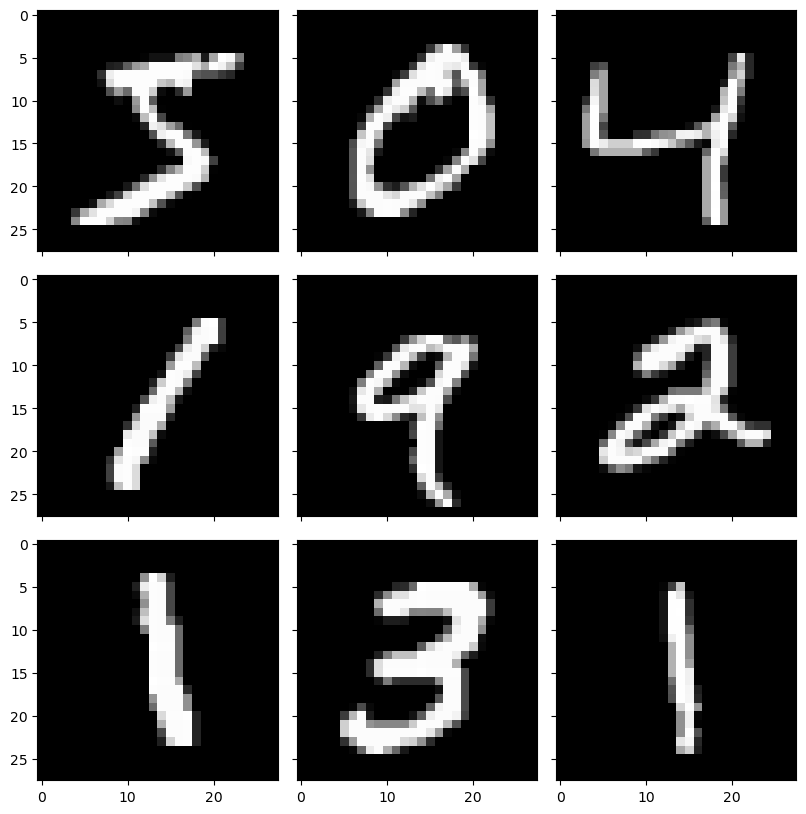

In [29]:
fig, axes = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(10, 10))
plt.subplots_adjust(wspace=.01, hspace=0.1)

ini = 100
step = 1
for i in range(9):
    # Mostrar os dados
    axes[i//3, i%3].imshow(X_train[i], cmap=plt.get_cmap('gray'))
plt.show()

## Tratamento de dados

Vamos precisar realizar um pequeno tratamento de dados, convertendo os dados em *float*, e em seguida normalizando os dados para que variem entre 0 e 1. Esta normalização pode ser feita de forma bem simples, dividindo o valor de cada pixel por 255.

In [30]:
# Pré-processamento dos dados de entrada
X_train = X_train.reshape(X_train.shape[0], 784) # Transforma os dados em vetores unidimensionais
X_test = X_test.reshape(X_test.shape[0], 784)
X_train = X_train.astype('float32') # Converte para float32
X_test = X_test.astype('float32')
X_train /= 255 # Normaliza os valores de pixel entre 0 e 1
X_test /= 255

# Pré-processamento dos dados de saída (rótulos)
Y_train = to_categorical(y_train, 10) # Converte os rótulos em vetores one-hot
Y_test = to_categorical(y_test, 10)

## Definindo o modelo

A seguir, vamos definir um modelo que se inicia com os 784 pixels como input, e os liga a 512 neurônios. Na camada seguinte teremos 256 neurônios, em seguida 128 depois 64, e finalmente 10 neurônios referentes à camada final.

A classificação será feita via softmax para se obter as probabilidades.

In [31]:
model = Sequential()
model.add(Dense(512, input_shape=(784,))) # Camada de entrada com 512 neurônios
model.add(Activation('relu')) # Função de ativação ReLU

model.add(Dense(256)) # Primeira camada escondida com 256 neurônios
model.add(Activation('relu'))

model.add(Dense(128)) # Segunda camada escondida com 128 neurônios
model.add(Activation('relu'))

model.add(Dense(64)) # Terceira camada escondida com 64 neurônios
model.add(Activation('relu'))

model.add(Dense(10)) # Camada de saída com 10 neurônios para classificação de 10 classes
model.add(Activation('softmax')) # Função de ativação Softmax

## Compilar o modelo

Esta etapa pode tomar um pouco de tempo dependendo do seu processador. É possivel utilizar uma placa gráfica se você tiver uma. Em especial, as placas da NVidia são mais fáceis de se usar através do pacote CUDA, mas é possível também utilizar as placas AMD da Radeon.

Utilizar placas gráficas acelera **substancialmente** o processamento do seu computador.

Para mais detalhes, você pode consultar o livro "Mãos à obra: aprendizado de máquina com scikit-learn, keras & tensorflot" de Aurélien Géron (que é o autor do TensorFlow).

In [32]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, Y_train, batch_size=128, epochs=10, verbose=1, validation_data=(X_test, Y_test))

Epoch 1/10
469/469 [==============================] - 5s 8ms/step - loss: 0.2410 - accuracy: 0.9288 - val_loss: 0.1422 - val_accuracy: 0.9548
Epoch 2/10
469/469 [==============================] - 4s 8ms/step - loss: 0.0906 - accuracy: 0.9719 - val_loss: 0.0842 - val_accuracy: 0.9741
Epoch 3/10
469/469 [==============================] - 4s 8ms/step - loss: 0.0583 - accuracy: 0.9822 - val_loss: 0.0946 - val_accuracy: 0.9701
Epoch 4/10
469/469 [==============================] - 4s 8ms/step - loss: 0.0431 - accuracy: 0.9860 - val_loss: 0.0711 - val_accuracy: 0.9790
Epoch 5/10
469/469 [==============================] - 4s 8ms/step - loss: 0.0353 - accuracy: 0.9881 - val_loss: 0.0743 - val_accuracy: 0.9780
Epoch 6/10
469/469 [==============================] - 4s 8ms/step - loss: 0.0292 - accuracy: 0.9903 - val_loss: 0.0898 - val_accuracy: 0.9770
Epoch 7/10
469/469 [==============================] - 4s 8ms/step - loss: 0.0262 - accuracy: 0.9915 - val_loss: 0.0697 - val_accuracy: 0.9815
Epoch 

## Avaliando o modelo

Vamos avaliar o modelo na base de testes, utilizando a acurácia. Como podemos ver, a acurácia é até bastante alta, 98%. Se pensarmos bem, para uma aplicação de OCR em que temos apenas 10 caracteres possíveis, um erro da ordem de 2 em cada 100 pode não ser o ideal.

Este problema tem uma vasta literatura, e pode ser melhorado com outras arquiteturas de rede e/ou aumentando o númeor de épocas. Mas creio que já deu pra "sentir" um básico de reconhecimento de imagens utilizando *deep learning*.

In [33]:
score = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.08674269169569016
Test accuracy: 0.9797999858856201
